# Construire un classificateur des k plus proches voisins

CSI 4506 — Introduction à l’intelligence artificielle

Marcel Turcotte  
2026-09-13

# Introduction

Ce cahier construit un petit classificateur des $k$ plus proches voisins
(KNN) à partir des principes fondamentaux. KNN illustre une approche de
l’apprentissage très différente de la construction d’un arbre de
décision ou de l’estimation des coefficients d’un modèle linéaire. Son
idée centrale tient en trois mots :

> **Mémoriser, chercher, voter.**

L’apprentissage consiste à mémoriser les exemples d’entraînement.
Lorsqu’une prédiction est demandée, le classificateur trouve les
exemples voisins et les fait voter. L’implémentation accepte plusieurs
classes ainsi que le vote uniforme et le vote pondéré par la distance.

# Préparation

L’installation ne s’exécute que si `palmerpenguins` est absent, ce qui
permet d’utiliser le cahier dans une nouvelle session Google Colab.

In [2]:
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    from palmerpenguins import load_penguins
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "palmerpenguins"
    ])
    from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Manchots de Palmer

Nous conservons la longueur et la profondeur du bec et classifions les
trois espèces de manchots. Ces deux attributs produisent un exemple
instructif : les classes sont discernables, sans être parfaitement
séparables. Modifier le voisinage change donc la frontière de décision.

In [3]:
feature_names = ["bill_length_mm", "bill_depth_mm"]

penguins = load_penguins()
penguins = penguins[feature_names + ["species"]].dropna().copy()

X = penguins[feature_names].to_numpy()
y = penguins["species"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Exemples d'entraînement : {len(X_train)}")
print(f"Exemples de test : {len(X_test)}")
print(f"Classes : {np.unique(y_train)}")

Exemples d'entraînement : 273
Exemples de test : 69
Classes : ['Adelie' 'Chinstrap' 'Gentoo']

# Mise à l’échelle des attributs

La distance euclidienne dépend de l’échelle numérique. Nous
standardisons donc chaque attribut à l’aide de la moyenne et de
l’écart-type du jeu d’entraînement :

$$
z=\frac{x-\mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}.
$$

Le transformateur est ajusté uniquement sur les données d’entraînement.
Les données de test ne doivent pas influencer les choix de prétraitement
effectués pendant l’apprentissage.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Recherche des voisins

Pour une requête $x$ et un exemple d’entraînement $x_i$, la distance
euclidienne est

$$
d(x,x_i)=\sqrt{\sum_{j=1}^{D}\left(x^{(j)}-x_i^{(j)}\right)^2}.
$$

L’implémentation la plus directe calcule toutes les distances, les trie
et conserve les $k$ premiers indices.

In [5]:
def nearest_neighbors(X_train, x, n_neighbors):
    """Retourner les indices des voisins et leur distance à x."""
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    indices = np.argsort(distances, kind="stable")[:n_neighbors]
    return indices, distances[indices]

Le tri stable rend le résultat déterministe lorsque deux exemples
d’entraînement se trouvent à la même distance. Les implémentations de
production peuvent éviter un tri complet ou utiliser des structures de
recherche spécialisées.

# Vote

Avec le vote uniforme, tous les voisins retenus reçoivent le poids 1.
Avec le vote pondéré par la distance, le voisin $i$ reçoit le poids

$$
w_i=\frac{1}{d_i}.
$$

Une correspondance exacte demande un traitement particulier, car $1/0$
n’est pas défini. S’il en existe, notre implémentation laisse seulement
ces observations voter.

In [6]:
def voting_weights(distances, mode):
    """Retourner des poids uniformes ou inverses à la distance."""
    if mode == "uniform":
        return np.ones(len(distances))

    exact_matches = distances == 0
    if np.any(exact_matches):
        return exact_matches.astype(float)

    return 1 / distances


def vote_probabilities(labels, weights, classes):
    """Convertir les votes pondérés des voisins en probabilités."""
    scores = np.array([
        np.sum(weights[labels == label])
        for label in classes
    ])
    return scores / np.sum(scores)

# Classificateur

La méthode `fit` mémorise le jeu d’entraînement. La majeure partie du
travail se fait dans `_predict_proba_one` : trouver les voisins, leur
attribuer des poids et regrouper leurs votes par classe.

La validation permet de produire des erreurs claires pour les entrées
non prises en charge, mais elle ne fait pas partie de l’idée centrale de
KNN.

In [7]:
class SimpleKNeighborsClassifier:
    """Un classificateur didactique avec une petite interface de type scikit-learn."""

    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self._validate_training_data(X, y)

        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def _predict_proba_one(self, x):
        indices, distances = nearest_neighbors(
            self.X_train_, x, self.n_neighbors
        )
        labels = self.y_train_[indices]
        weights = voting_weights(distances, self.weights)
        return vote_probabilities(labels, weights, self.classes_)

    def predict_proba(self, X):
        X = self._validate_prediction_data(X)
        return np.vstack([self._predict_proba_one(x) for x in X])

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))

    def _validate_training_data(self, X, y):
        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError(
                "X doit être 2D et y doit être 1D, avec le même nombre de lignes"
            )
        if len(y) == 0:
            raise ValueError("le jeu d'entraînement ne peut pas être vide")
        if not np.isfinite(X).all():
            raise ValueError(
                "les valeurs manquantes ou non finies ne sont pas prises en charge"
            )
        if not isinstance(self.n_neighbors, (int, np.integer)):
            raise ValueError("n_neighbors doit être un entier")
        if not 1 <= self.n_neighbors <= len(y):
            raise ValueError("n_neighbors doit être compris entre 1 et len(y)")
        if self.weights not in {"uniform", "distance"}:
            raise ValueError("weights doit être 'uniform' ou 'distance'")

    def _validate_prediction_data(self, X):
        if not hasattr(self, "X_train_"):
            raise ValueError("appelez fit avant d'effectuer des prédictions")
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X n'a pas le bon nombre d'attributs")
        if not np.isfinite(X).all():
            raise ValueError(
                "les valeurs manquantes ou non finies ne sont pas prises en charge"
            )
        return X

# Entraînement et évaluation

Les deux modèles ci-dessous utilisent les cinq mêmes voisins. Seule leur
règle de vote change.

In [8]:
for mode in ("uniform", "distance"):
    knn = SimpleKNeighborsClassifier(n_neighbors=5, weights=mode)
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    print(f"k=5, weights='{mode}' : exactitude={accuracy:.3f}")

k=5, weights='uniform' : exactitude=0.957
k=5, weights='distance' : exactitude=0.957

## Examiner une prédiction

Puisque KNN fonde directement une prédiction sur les exemples mémorisés,
nous pouvons examiner le voisinage responsable d’un résultat
particulier.

In [9]:
query = X_test_scaled[0]
indices, distances = nearest_neighbors(X_train_scaled, query, n_neighbors=5)

print(f"Classe réelle : {y_test[0]}")
print(f"Classe prédite : {knn.predict(query)[0]}")
print("\nVoisins :")
for rank, (index, distance) in enumerate(zip(indices, distances), start=1):
    print(f"{rank} : {y_train[index]:9s} distance={distance:.3f}")

Classe réelle : Adelie
Classe prédite : Adelie

Voisins :
1 : Adelie    distance=0.018
2 : Adelie    distance=0.053
3 : Adelie    distance=0.088
4 : Adelie    distance=0.100
5 : Adelie    distance=0.128

# Frontières de décision

Notre classificateur suffit pour effectuer des prédictions, mais lui
faire calculer quatre grilles denses détournerait l’attention de sa
logique essentielle. La visualisation suivante utilise donc les versions
optimisées de `KNeighborsClassifier` et de `DecisionBoundaryDisplay` de
scikit-learn.

Un pipeline standardise les attributs à l’interne, ce qui permet de
conserver leurs unités originales sur les axes.

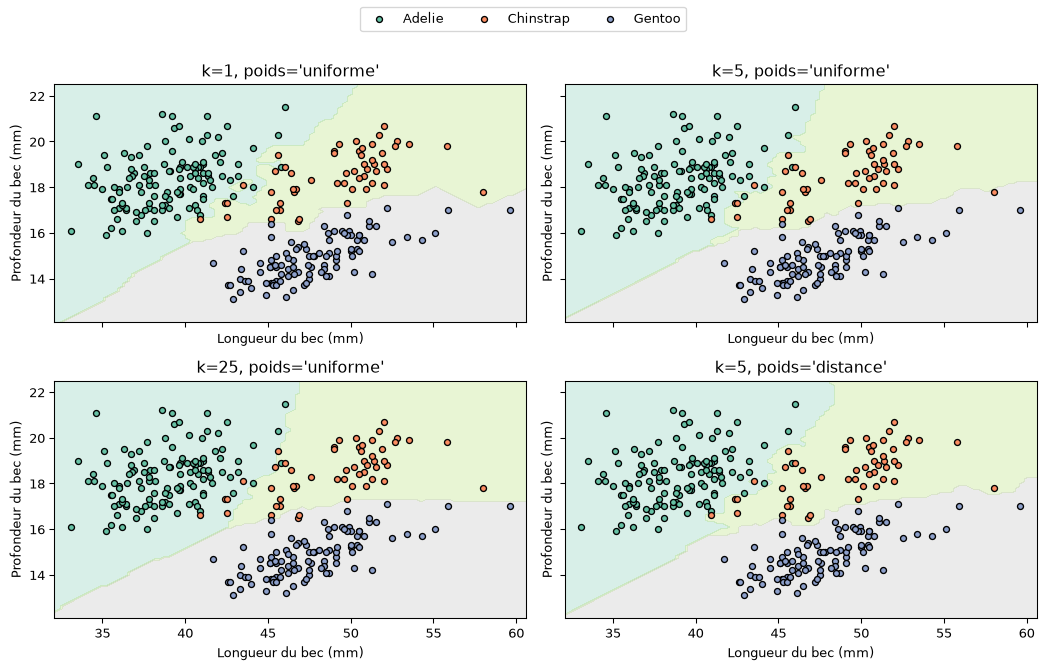

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

configurations = [
    (1, "uniform"),
    (5, "uniform"),
    (25, "uniform"),
    (5, "distance"),
]
weight_names = {"uniform": "uniforme", "distance": "distance"}
classes, y_encoded = np.unique(y_train, return_inverse=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (n_neighbors, weights) in zip(axes.ravel(), configurations):
    sklearn_knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights),
    )
    sklearn_knn.fit(X_train, y_encoded)
    DecisionBoundaryDisplay.from_estimator(
        sklearn_knn,
        X_train,
        response_method="predict",
        multiclass_colors="Set2",
        alpha=0.25,
        ax=ax,
    )

    for label, name in enumerate(classes):
        selected = y_encoded == label
        ax.scatter(
            X_train[selected, 0],
            X_train[selected, 1],
            color=plt.get_cmap("Set2")(label),
            edgecolor="black",
            s=20,
            label=name,
        )

    ax.set_title(f"k={n_neighbors}, poids='{weight_names[weights]}'")
    ax.set_xlabel("Longueur du bec (mm)")
    ax.set_ylabel("Profondeur du bec (mm)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=len(classes))
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

Avec $k=1$, des observations d’entraînement individuelles contrôlent de
petites régions, ce qui produit une frontière très irrégulière.
Augmenter $k$ lisse la frontière, car un voisinage plus grand doit
s’accorder. La pondération par la distance permet aux observations
proches de conserver une plus grande influence locale.

# Régression

La recherche des voisins ne change pas pour la régression. Nous
remplaçons le vote des classes par une moyenne pondérée des cibles
numériques :

In [11]:
def regression_prediction(targets, distances, mode="uniform"):
    weights = voting_weights(distances, mode)
    return float(np.average(targets, weights=weights))

Puisque le résultat est une moyenne des cibles observées dans le
voisinage, la régression KNN ordinaire n’extrapole pas au-delà de leur
étendue.

# Complexité et limites

Pour chaque requête, cette implémentation directe calcule les distances
en $\mathcal{O}(ND)$ et effectue un tri complet en
$\mathcal{O}(N\log N)$. Elle conserve également le jeu d’entraînement de
taille $\mathcal{O}(ND)$ en mémoire.

Parmi les autres limites importantes :

- les distances sont sensibles à l’échelle des attributs et à la
  métrique choisie;
- les voisinages deviennent moins informatifs dans les espaces de grande
  dimension;
- un petit $k$ peut être sensible au bruit, tandis qu’un grand $k$ peut
  masquer la structure locale;
- le déséquilibre des classes peut dominer le vote d’un voisinage.

# Expériences suggérées

1.  Comparez l’exactitude sur le jeu de test pour plusieurs valeurs de
    `n_neighbors`.
2.  Modifiez les quatre configurations de la figure des frontières de
    décision.
3.  Retirez la standardisation et observez comment les résultats
    changent.
4.  Remplacez la distance euclidienne par la distance de Manhattan.
5.  Créez une requête identique à un exemple d’entraînement et examinez
    la pondération par la distance.
6.  Comparez cette implémentation au `KNeighborsClassifier` de
    scikit-learn.